# Auto ARIMA Benchmark

Every automatic-ARIMA implementation on the M1 + M3 + Tourism series, scored on
the **same** metrics as the ETS benchmark: point accuracy (**RMSSE**, **SAME**),
**computational time**, and the predictive distribution (**calibration** /
reliability at levels `seq(0.01, 0.99, 0.01)` and **scaled pinball** loss).

Methods:

- **smooth `AutoMSARIMA`** — backcasting / optimal / two-stage initialisation.
- **statsforecast `AutoARIMA`**, **sktime `AutoARIMA`** (pmdarima backend,
  `approximation=True`), **skforecast `Arima`** (auto), **aeon `AutoARIMA`**.

Quantiles come from each package's predictive distribution; **aeon exposes no
quantile API**, so its calibration/pinball are `NaN`. The heavy fit+forecast run
(one fit per series produces point **and** 99 quantiles) lives in
`run_arima_benchmark.py`. Because auto-ARIMA order search (pmdarima especially)
is far heavier than AutoETS, the saved run uses a **stratified subsample** of the
series (stride across M1/M3/Tourism); set `BENCH_N=0` to run the full set.

In [1]:
import glob, os, subprocess, sys
import numpy as np, pandas as pd
pd.set_option("display.width", 200)

LEVELS = np.round(np.arange(0.01, 1.0, 0.01), 2)
METHOD_NAMES = ["AutoMSARIMA Back", "AutoMSARIMA Opt", "AutoMSARIMA Two",
                "statsforecast AutoARIMA", "sktime AutoARIMA (pmdarima)",
                "skforecast Arima", "aeon AutoARIMA"]

# Recompute only if asked; otherwise load the saved results.
if os.environ.get("BENCH_RERUN_ARIMA", "0") == "1":
    subprocess.run([sys.executable, "run_arima_benchmark.py"], check=True)

pt_file = sorted(glob.glob("*-benchmark-arima-point.npy"))[-1]
di_file = sorted(glob.glob("*-benchmark-arima-dist.npy"))[-1]
point_results = np.load(pt_file)          # (M, N, 3) rmsse, same, time
dist_results  = np.load(di_file)          # (M, N, 99, 2) scaled pinball, coverage
n_methods = point_results.shape[0]; n_series = point_results.shape[1]
print(f"loaded {pt_file} and {di_file}")
print(f"methods={n_methods}  series (subsample)={n_series}")
assert n_methods == len(METHOD_NAMES)


loaded 2026-07-23-benchmark-arima-point.npy and 2026-07-23-benchmark-arima-dist.npy
methods=7  series (subsample)=300


## Point accuracy & time

In [2]:
mi = 0
summary = pd.DataFrame({
    "Method": METHOD_NAMES,
    "Min": [np.nanmin(point_results[j, :, mi]) for j in range(n_methods)],
    "Q1": [np.nanquantile(point_results[j, :, mi], 0.25) for j in range(n_methods)],
    "Med": [np.nanmedian(point_results[j, :, mi]) for j in range(n_methods)],
    "Q3": [np.nanquantile(point_results[j, :, mi], 0.75) for j in range(n_methods)],
    "Max": [np.nanmax(point_results[j, :, mi]) for j in range(n_methods)],
    "Mean": [np.nanmean(point_results[j, :, mi]) for j in range(n_methods)],
    "Mean Time (s)": [np.nanmean(point_results[j, :, 2]) for j in range(n_methods)],
    "Failed": [int(np.sum(np.isnan(point_results[j, :, mi]))) for j in range(n_methods)],
}).sort_values("Mean")
print("\n" + "=" * 92 + "\nRMSSE (subsample)\n" + "=" * 92)
print(summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))



RMSSE (subsample)
                     Method    Min     Q1    Med     Q3     Max   Mean  Mean Time (s)  Failed
    statsforecast AutoARIMA 0.1135 0.7340 1.3216 2.1552 36.4096 2.1018         1.4576       2
           AutoMSARIMA Back 0.1135 0.7681 1.3690 2.2021 36.4522 2.1710         1.5676       0
            AutoMSARIMA Opt 0.1078 0.7688 1.3289 2.4148 35.6142 2.2344         2.0047       0
sktime AutoARIMA (pmdarima) 0.1790 1.0857 1.7768 2.9974  8.5116 2.2959        18.5464     217
            AutoMSARIMA Two 0.0851 0.9448 1.5345 2.5891 38.3044 2.4307         2.0398       0
             aeon AutoARIMA 0.1223 0.9241 1.6043 2.7601 43.1508 2.5163         0.0532       0
           skforecast Arima 0.1014 1.1753 1.9070 3.4395 30.7511 2.6923         0.1118       0


In [3]:
mi = 1
summary = pd.DataFrame({
    "Method": METHOD_NAMES,
    "Min": [np.nanmin(point_results[j, :, mi]) for j in range(n_methods)],
    "Q1": [np.nanquantile(point_results[j, :, mi], 0.25) for j in range(n_methods)],
    "Med": [np.nanmedian(point_results[j, :, mi]) for j in range(n_methods)],
    "Q3": [np.nanquantile(point_results[j, :, mi], 0.75) for j in range(n_methods)],
    "Max": [np.nanmax(point_results[j, :, mi]) for j in range(n_methods)],
    "Mean": [np.nanmean(point_results[j, :, mi]) for j in range(n_methods)],
    "Mean Time (s)": [np.nanmean(point_results[j, :, 2]) for j in range(n_methods)],
    "Failed": [int(np.sum(np.isnan(point_results[j, :, mi]))) for j in range(n_methods)],
}).sort_values("Mean")
print("\n" + "=" * 92 + "\nSAME (subsample)\n" + "=" * 92)
print(summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))



SAME (subsample)
                     Method    Min     Q1    Med     Q3     Max   Mean  Mean Time (s)  Failed
    statsforecast AutoARIMA 0.0039 0.5036 1.0835 2.3854 42.5334 2.1410         1.4576       2
           AutoMSARIMA Back 0.0046 0.4313 1.1383 2.4647 42.5874 2.2122         1.5676       0
            AutoMSARIMA Opt 0.0026 0.4553 1.1698 2.6694 41.5250 2.3149         2.0047       0
            AutoMSARIMA Two 0.0130 0.4624 1.3836 2.7660 44.6574 2.4565         2.0398       0
sktime AutoARIMA (pmdarima) 0.0078 0.6660 2.0285 3.1454  9.4239 2.4627        18.5464     217
             aeon AutoARIMA 0.0029 0.5831 1.3119 2.8318 49.9901 2.5296         0.0532       0
           skforecast Arima 0.0007 0.8437 2.0458 4.0016 37.3737 2.8656         0.1118       0


In [4]:
mi = 2
summary = pd.DataFrame({
    "Method": METHOD_NAMES,
    "Min": [np.nanmin(point_results[j, :, mi]) for j in range(n_methods)],
    "Q1": [np.nanquantile(point_results[j, :, mi], 0.25) for j in range(n_methods)],
    "Med": [np.nanmedian(point_results[j, :, mi]) for j in range(n_methods)],
    "Q3": [np.nanquantile(point_results[j, :, mi], 0.75) for j in range(n_methods)],
    "Max": [np.nanmax(point_results[j, :, mi]) for j in range(n_methods)],
    "Mean": [np.nanmean(point_results[j, :, mi]) for j in range(n_methods)],
    "Total (min)": [np.nansum(point_results[j, :, 2]) / 60 for j in range(n_methods)],
    "Failed": [int(np.sum(np.isnan(point_results[j, :, mi]))) for j in range(n_methods)],
}).sort_values("Mean")
print("\n" + "=" * 92 + "\nComputational time, seconds (subsample)\n" + "=" * 92)
print(summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))



Computational time, seconds (subsample)
                     Method    Min      Q1     Med      Q3     Max    Mean  Total (min)  Failed
             aeon AutoARIMA 0.0018  0.0169  0.0257  0.0450  0.8521  0.0532       0.2658       0
           skforecast Arima 0.0080  0.0319  0.0597  0.1046  1.5344  0.1118       0.5590       0
    statsforecast AutoARIMA 0.0409  0.2713  0.6131  1.4279 39.1230  1.4576       7.2395       2
           AutoMSARIMA Back 0.0817  0.3273  0.6143  1.8819 12.2660  1.5676       7.8378       0
            AutoMSARIMA Opt 0.1443  0.4355  1.8390  2.9149  7.7128  2.0047      10.0234       0
            AutoMSARIMA Two 0.2354  0.5605  0.7981  1.8018 14.8258  2.0398      10.1989       0
sktime AutoARIMA (pmdarima) 4.8864 10.4859 15.3340 24.7306 40.4469 18.5464      25.6558     217


## Predictive distribution: calibration + pinball

In [5]:
_pin = dist_results[:, :, :, 0]           # scaled pinball (M, N, 99)
_cov = dist_results[:, :, :, 1]           # coverage       (M, N, 99)
_pin_series = np.nanmean(_pin, axis=2)    # (M, N) mean over levels

rows = []
for j, name in enumerate(METHOD_NAMES):
    cov_curve = np.nanmean(_cov[j], axis=0)
    if np.all(np.isnan(cov_curve)):
        rows.append({"Method": name, "Mean Pinball": np.nan, "Median Pinball": np.nan,
                     "MCE": np.nan, "Cov@0.1": np.nan, "Cov@0.5": np.nan,
                     "Cov@0.9": np.nan, "n": 0})
        continue
    rows.append({"Method": name,
                 "Mean Pinball": np.nanmean(_pin[j]),
                 "Median Pinball": np.nanmedian(_pin_series[j]),
                 "MCE": np.nanmean(np.abs(cov_curve - LEVELS)),
                 "Cov@0.1": cov_curve[9], "Cov@0.5": cov_curve[49], "Cov@0.9": cov_curve[89],
                 "n": int(np.sum(~np.isnan(_pin_series[j])))})
summary_dist = pd.DataFrame(rows).sort_values("Median Pinball")
print("\n" + "=" * 100)
print("PREDICTIVE DISTRIBUTION: scaled pinball + calibration MCE (lower=better)")
print("=" * 100)
print(summary_dist.to_string(index=False, float_format=lambda x: f"{x:.4f}"))



PREDICTIVE DISTRIBUTION: scaled pinball + calibration MCE (lower=better)
                     Method  Mean Pinball  Median Pinball    MCE  Cov@0.1  Cov@0.5  Cov@0.9   n
            AutoMSARIMA Opt        0.9889          0.5336 0.0469   0.1163   0.4512   0.8121 300
    statsforecast AutoARIMA        0.9305          0.5413 0.0505   0.1301   0.4521   0.8134 298
           AutoMSARIMA Back        0.9530          0.5525 0.0492   0.1086   0.4450   0.8143 300
            AutoMSARIMA Two        1.0866          0.6250 0.0354   0.1487   0.5012   0.8299 300
sktime AutoARIMA (pmdarima)        1.0626          0.7324 0.1107   0.1391   0.3991   0.6968  83
           skforecast Arima        1.2102          0.8326 0.1421   0.0823   0.3382   0.6668 300
             aeon AutoARIMA           NaN             NaN    NaN      NaN      NaN      NaN   0


/tmp/ipykernel_198377/693729368.py:3: RuntimeWarning: Mean of empty slice
  _pin_series = np.nanmean(_pin, axis=2)    # (M, N) mean over levels
/tmp/ipykernel_198377/693729368.py:7: RuntimeWarning: Mean of empty slice
  cov_curve = np.nanmean(_cov[j], axis=0)


/tmp/ipykernel_198377/634250845.py:5: RuntimeWarning: Mean of empty slice
  cov = np.nanmean(_cov[j], axis=0)


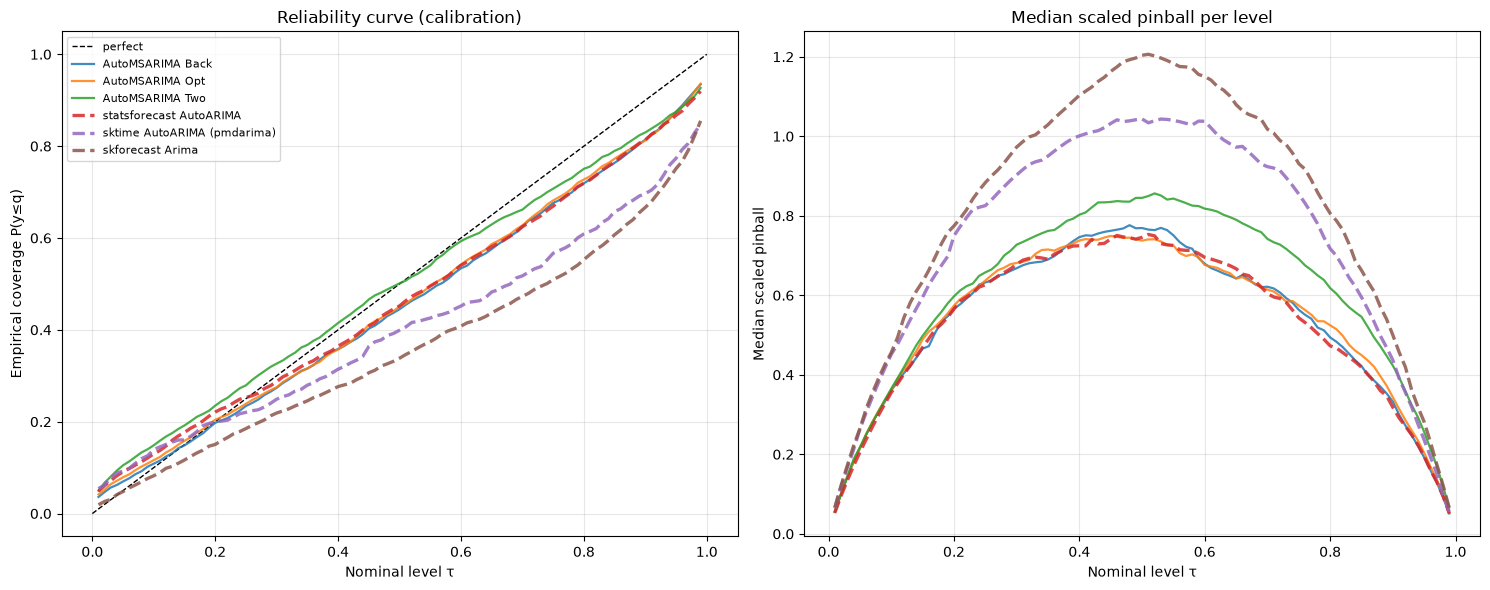

In [6]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
ax[0].plot([0, 1], [0, 1], "k--", lw=1, label="perfect")
for j, name in enumerate(METHOD_NAMES):
    cov = np.nanmean(_cov[j], axis=0)
    if np.all(np.isnan(cov)):
        continue
    sm = name.startswith("AutoMSARIMA")
    ax[0].plot(LEVELS, cov, lw=1.6 if sm else 2.4, ls="-" if sm else "--", alpha=0.85, label=name)
    ax[1].plot(LEVELS, np.nanmedian(_pin[j], axis=0), lw=1.6 if sm else 2.4,
               ls="-" if sm else "--", alpha=0.85, label=name)
ax[0].set(title="Reliability curve (calibration)", xlabel="Nominal level \u03c4",
          ylabel="Empirical coverage P(y\u2264q)")
ax[1].set(title="Median scaled pinball per level", xlabel="Nominal level \u03c4",
          ylabel="Median scaled pinball")
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
